## Grocery Dataset Clustering & Analysis
- In this notebook, we will perform unsupervised machine learning to segment grocery store products and understand purchasing patterns. 
- We'll analyze purchasing patterns and group similar products to identify market segments.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**Load Dataset**

In [11]:
data_path = "GroceryDataset.csv"
df = pd.read_csv(data_path)

In [12]:
display(df.head(2))

,Sub Category,Price,Discount,Rating,Title,Currency,Feature,Product Description
0,Bakery & Desserts,$56.99,No Discount,Rated 4.3 out of 5 stars based on 265 reviews.,"David’s Cookies Mile High Peanut Butter Cake, ...",$,"""10"""" Peanut Butter Cake\nCertified Kosher OU-...",A cake the dessert epicure will die for!Our To...
1,Bakery & Desserts,$159.99,No Discount,Rated 5 out of 5 stars based on 1 reviews.,"The Cake Bake Shop 8"" Round Carrot Cake (16-22...",$,Spiced Carrot Cake with Cream Cheese Frosting ...,"Due to the perishable nature of this item, ord..."


In [13]:
# Check basic information about the dataset
print("\nDataset Information:")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")


Dataset Information:
Number of records: 1757
Number of features: 8


In [24]:
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Sub Category              0
Price                     3
Discount                  0
Rating                 1197
Title                     0
Currency                  5
Feature                  18
Product Description      42
dtype: int64


### Data Cleaning & Preprocessing

In [25]:
# Convert 'Price' column to numerical
if df['Price'].dtype == object:
    df['Price'] = df['Price'].str.extract(r'(\d+\.\d+)')  # Extract only numerical values
    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')  # Convert to float

In [27]:
# Extract numerical rating from text
if df['Rating'].dtype == object:
    df['Rating'] = df['Rating'].str.extract(r'(\d+\.\d+)').astype(float)

In [28]:
# Convert 'Discount' column to categorical
if df['Discount'].dtype == object:
    df['Discount'] = df['Discount'].apply(lambda x: 0 if 'No Discount' in str(x) else 1)  # Convert to binary

In [29]:
# Encode categorical variables
le = LabelEncoder()
df['Sub Category'] = le.fit_transform(df['Sub Category'])

In [30]:
# Selecting relevant features
features = ['Sub Category', 'Price', 'Discount', 'Rating']
df_selected = df[features].copy()

In [31]:
# Handling missing values
df_selected.fillna(df_selected.mean(numeric_only=True), inplace=True)

In [32]:
display(df_selected.head())

,Sub Category,Price,Discount,Rating
0,0,56.99,0,4.300000
1,0,159.99,0,4.369643
2,0,44.99,0,4.100000
3,0,39.99,0,4.700000
4,0,59.99,0,4.500000


### Exploratory Data Analysis (EDA)

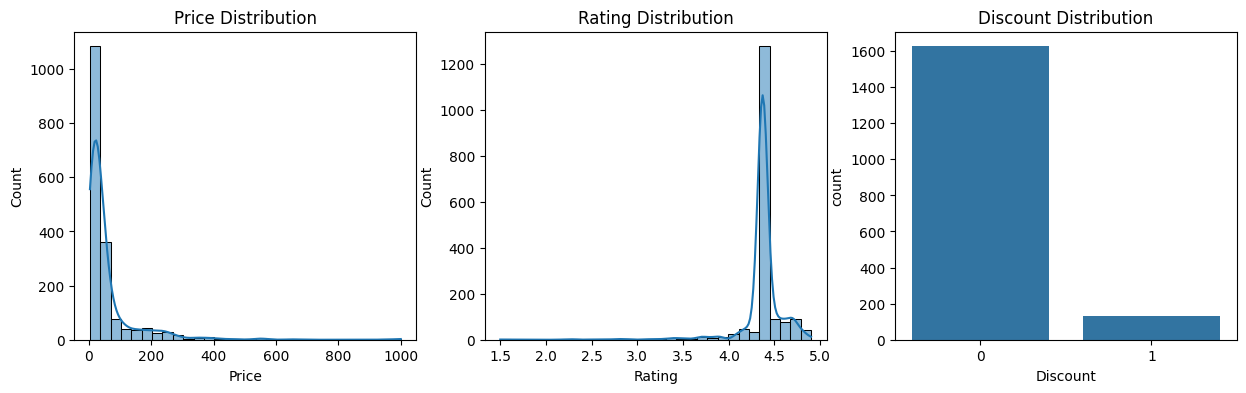

In [24]:
# Visualizing distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df_selected['Price'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')
sns.histplot(df_selected['Rating'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Rating Distribution')
sns.countplot(x=df_selected['Discount'], ax=axes[2])
axes[2].set_title('Discount Distribution')
plt.show()

### Standardization & Clustering

In [34]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_selected)

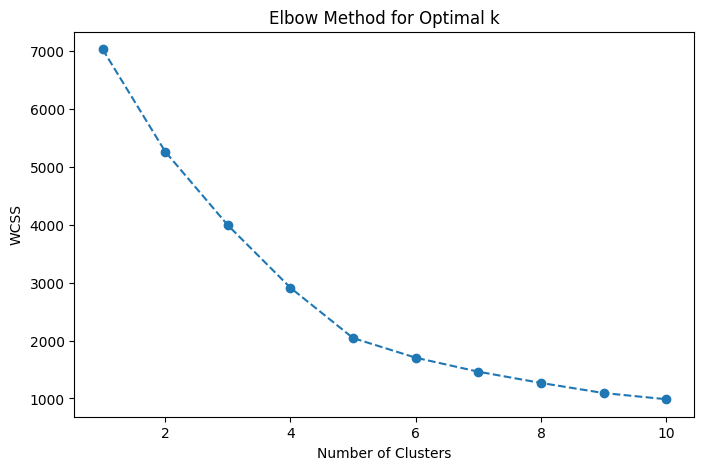

In [35]:
# Determine optimal number of clusters using the elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

### Applying K-Means Clustering

In [42]:
# Applying K-Means with optimal clusters (e.g., k=4)
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)


Distribution of items across clusters:
Cluster
0    131
1    720
2    128
3    778
Name: count, dtype: int64


C:\Users\muhamsaj\AppData\Local\Temp\ipykernel_24140\3143289023.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Cluster'], palette='viridis')


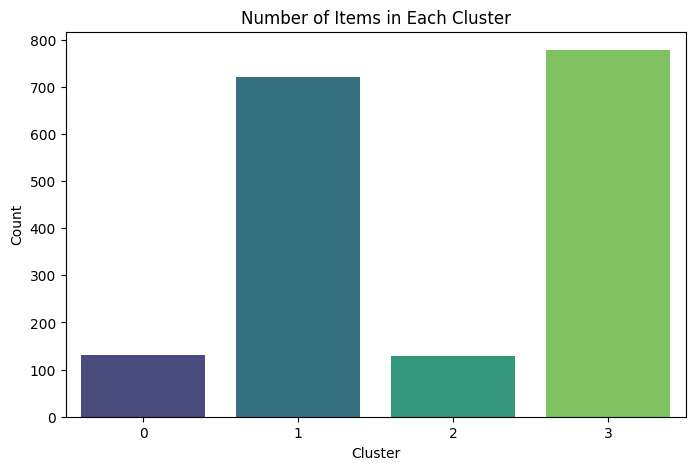

In [43]:
# Show distribution of clusters
cluster_counts = df['Cluster'].value_counts().sort_index()
print("\nDistribution of items across clusters:")
print(cluster_counts)

plt.figure(figsize=(8, 5))
sns.countplot(x=df['Cluster'], palette='viridis')
plt.title('Number of Items in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

### Visualizing Clusters with PCA

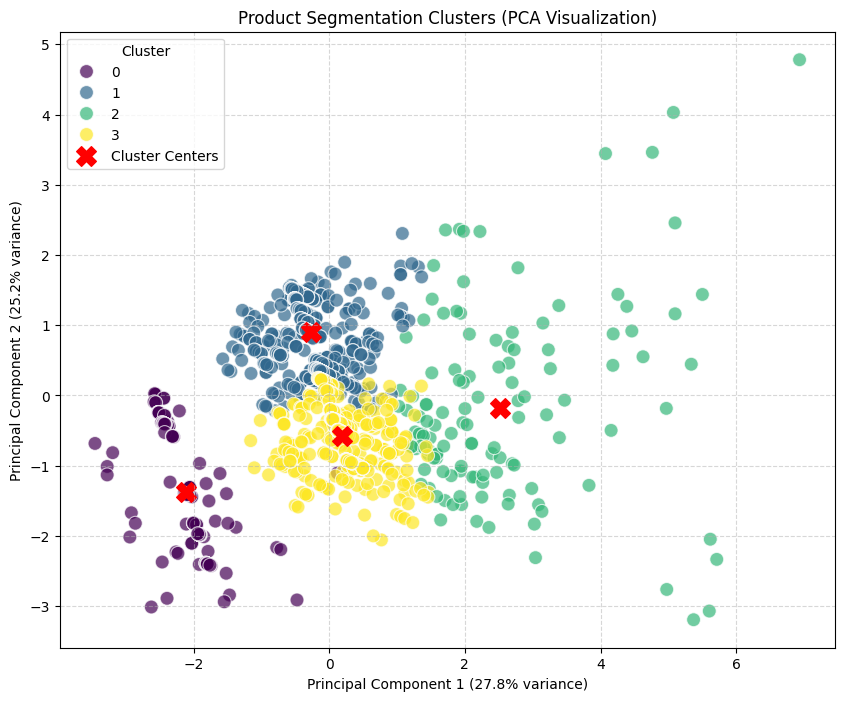

In [44]:
# PCA helps visualize high-dimensional data in 2D
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(df_scaled)

# Add PCA components to the dataframe
df['PCA1'] = pca_transformed[:, 0]
df['PCA2'] = pca_transformed[:, 1]

# ### 7.2 Visualize clusters in 2D PCA space
plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    data=df,
    palette='viridis',
    s=100,
    alpha=0.7
)

# Add cluster centers to the plot
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], 
    centers[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Cluster Centers'
)

plt.title('Product Segmentation Clusters (PCA Visualization)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

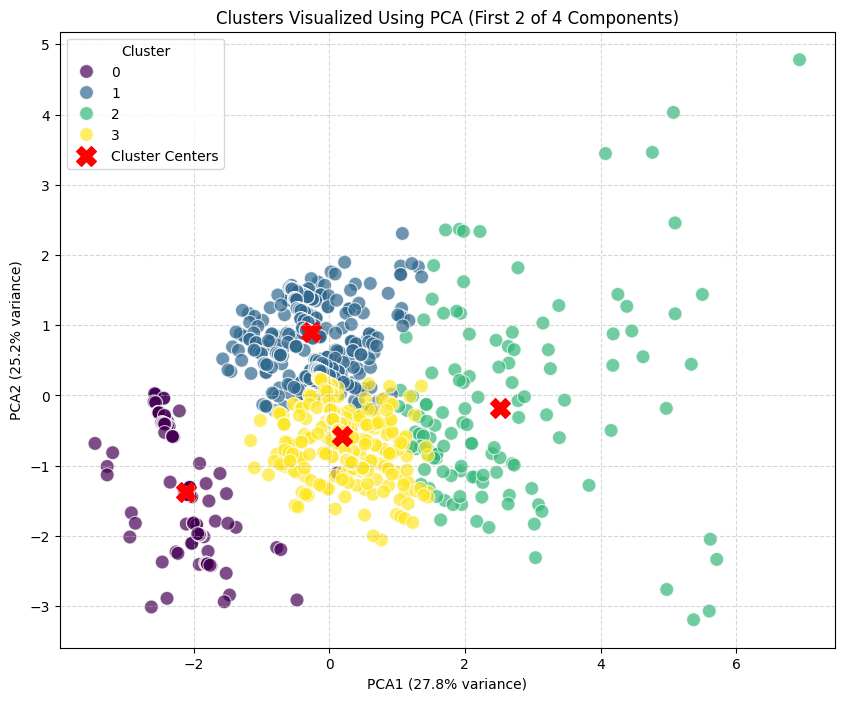

In [46]:
# PCA with 4 principal components
pca = PCA(n_components=4)
pca_transformed = pca.fit_transform(df_scaled)

# Add PCA components to the dataframe
df['PCA1'] = pca_transformed[:, 0]
df['PCA2'] = pca_transformed[:, 1]
df['PCA3'] = pca_transformed[:, 2]
df['PCA4'] = pca_transformed[:, 3]

# Visualize using only first 2 components (because we cannot plot 4D)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.7
)

# Add cluster centers after PCA transformation
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], 
    centers[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Cluster Centers'
)

plt.title('Clusters Visualized Using PCA (First 2 of 4 Components)')
plt.xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


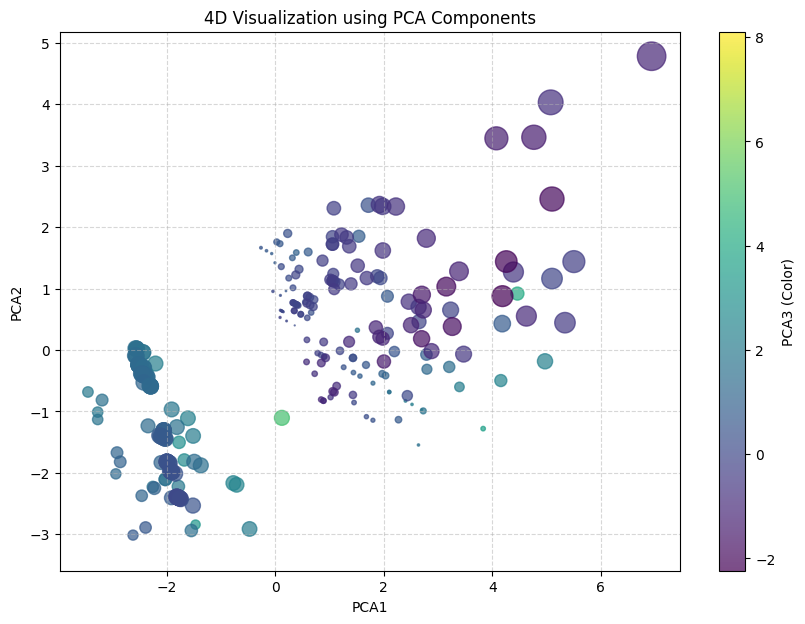

In [45]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df['PCA1'],        # 1st dimension (x-axis)
    df['PCA2'],        # 2nd dimension (y-axis)
    c=df['PCA3'],      # 3rd dimension encoded by color
    s=df['PCA4'] * 50, # 4th dimension encoded by point size
    alpha=0.7,
    cmap='viridis'
)

plt.colorbar(label="PCA3 (Color)")
plt.title("4D Visualization using PCA Components")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [47]:
pca = PCA(n_components=4)
pca_transformed = pca.fit_transform(df_scaled)

df['PC1'] = pca_transformed[:, 0]
df['PC2'] = pca_transformed[:, 1]
df['PC3'] = pca_transformed[:, 2]
df['PC4'] = pca_transformed[:, 3]


c:\Users\muhamsaj\anaconda3\envs\workenv\lib\site-packages\matplotlib\collections.py:963: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


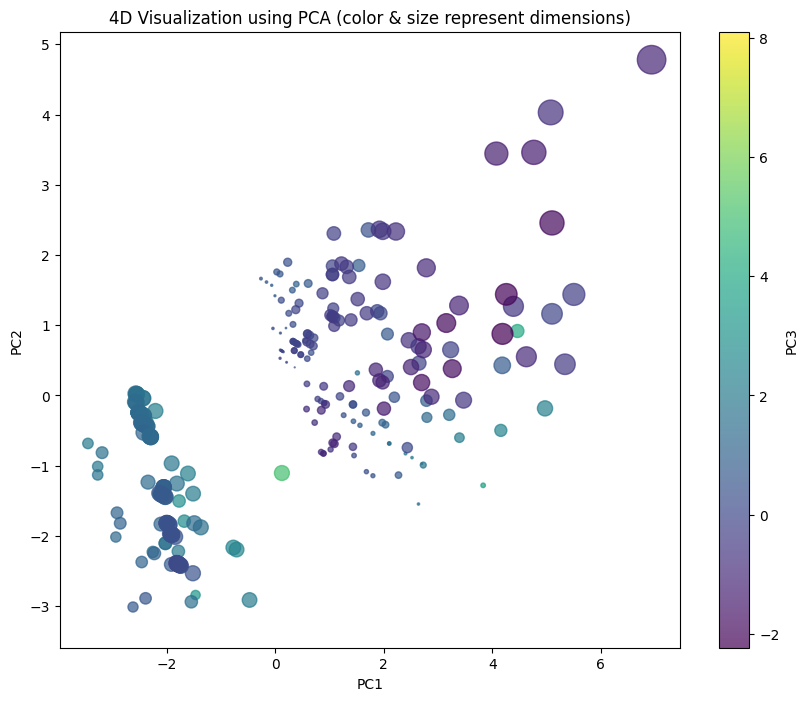

In [48]:
plt.figure(figsize=(10, 8))
plt.scatter(
    df['PC1'], 
    df['PC2'],
    c=df['PC3'],           # 3rd dimension encoded as color
    s=(df['PC4'] * 50),    # 4th dimension encoded as size
    alpha=0.7,
    cmap='viridis'
)
plt.colorbar(label='PC3')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("4D Visualization using PCA (color & size represent dimensions)")
plt.show()


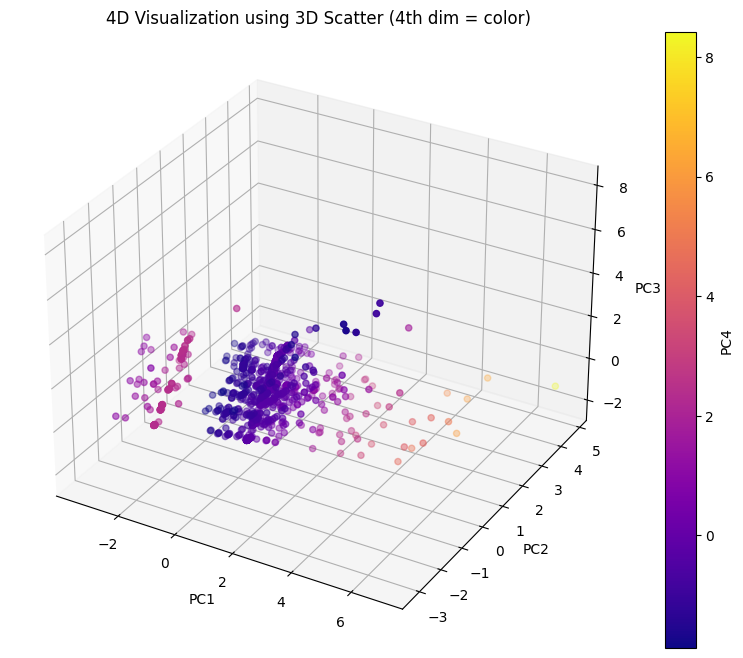

In [49]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    df['PC1'], df['PC2'], df['PC3'],
    c=df['PC4'], cmap='plasma'
)

fig.colorbar(sc, label="PC4")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.title("4D Visualization using 3D Scatter (4th dim = color)")
plt.show()


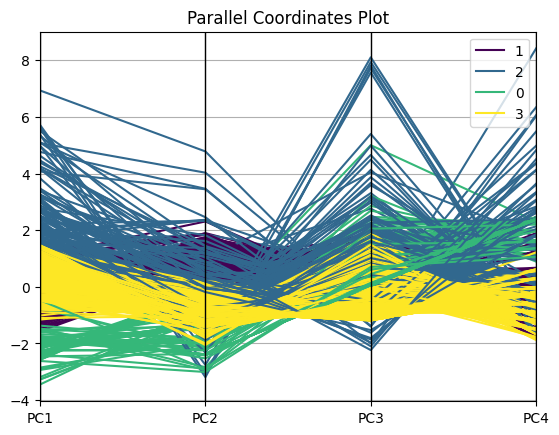

In [50]:
from pandas.plotting import parallel_coordinates

parallel_coordinates(df[['PC1','PC2','PC3','PC4','Cluster']], 'Cluster', colormap='viridis')
plt.title("Parallel Coordinates Plot")
plt.show()


c:\Users\muhamsaj\anaconda3\envs\workenv\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


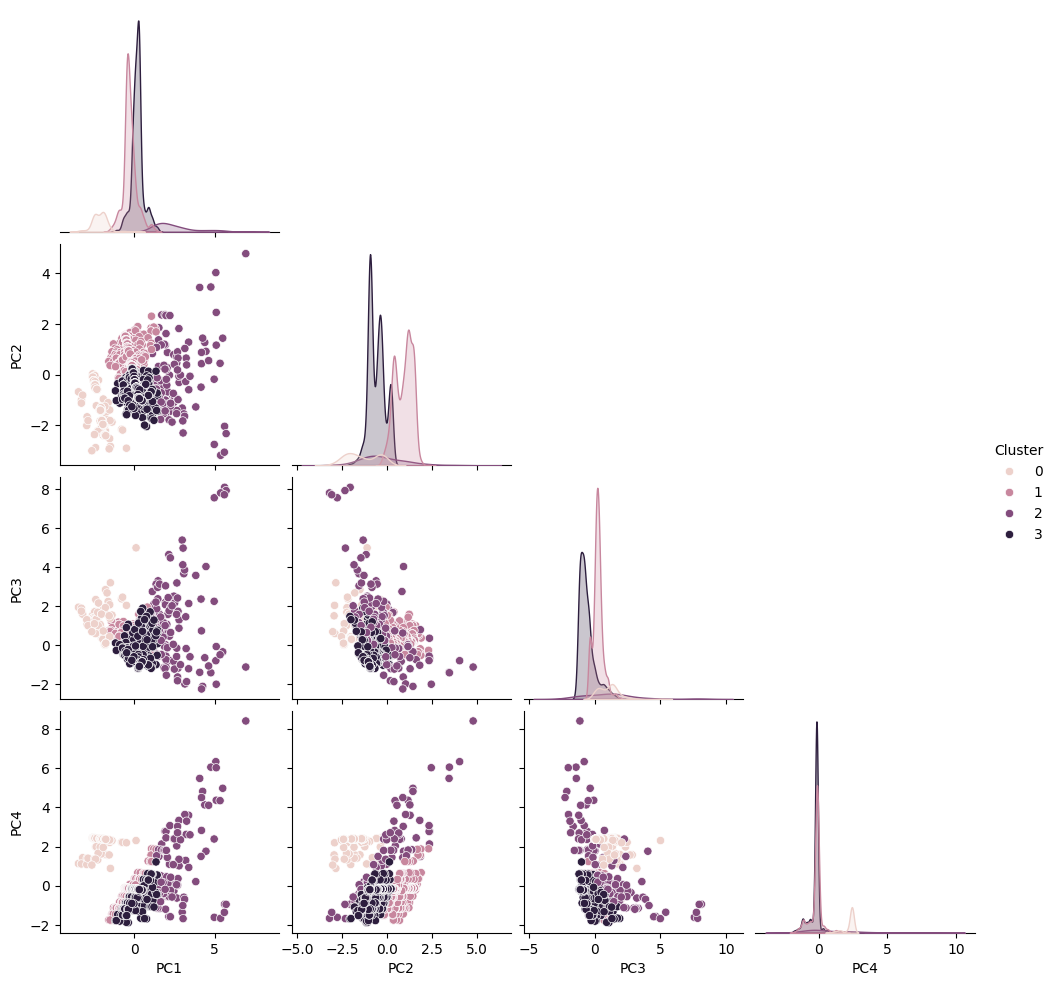

In [51]:
sns.pairplot(df[['PC1','PC2','PC3','PC4','Cluster']], hue='Cluster', corner=True)
plt.show()


### Cluster Analysis

In [20]:
# Compute mean values for each cluster
display(df.groupby('Cluster')[['Price', 'Discount', 'Rating']].mean())

,Price,Discount,Rating
Cluster,,,
0,43.186875,1.0,4.603448
1,39.799722,0.0,4.450667
2,274.240000,0.0,3.878761
3,41.578123,0.0,4.527461


---